# Modelo A — Notebook de experimentación (versión corregida)

Esta versión corrige dos problemas que aparecieron en tu ejecución:

1. **panel vacío** porque la base de datos se resolvía con una ruta relativa y el notebook podía abrirse fuera de la raíz del proyecto;
2. **`KeyError: is_observed_price`** porque el notebook seguía adelante aunque el panel estuviera vacío.

Ahora el flujo hace esto:

- localiza la raíz del repo,
- cambia el directorio de trabajo a esa raíz,
- usa explícitamente la ruta de SQLite del proyecto,
- ejecuta un diagnóstico antes de cargar el panel,
- corta con un error claro si no hay datos,
- calibra con manejo de errores por horizonte.


## 1. Setup del proyecto


In [1]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start] + list(start.parents)
    for p in candidates:
        if (p / "src").exists() and (p / "data").exists():
            return p
    raise FileNotFoundError(
        "No se ha encontrado la raíz del repositorio. "
        "Ejecuta el notebook desde el proyecto o fija REPO_ROOT manualmente."
    )

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print("REPO_ROOT =", REPO_ROOT)
print("CWD =", Path.cwd())


REPO_ROOT = /Users/juanlu/Repositorios/FuelPrice-Predictor
CWD = /Users/juanlu/Repositorios/FuelPrice-Predictor


## 2. Imports y diagnóstico de base de datos


In [2]:
import json
import os
import sqlite3
import traceback
import warnings
import time
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from tqdm.auto import tqdm

from src import config
from src.database import Database
from src.model_a import (
    FuelDecisionModelA,
    WaitBuyDecisionPolicy,
    build_default_panel,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

/Users/juanlu/.pyenv/versions/3.11.14/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2.b Progreso y tiempos

Las celdas de calibración y backtest rolling muestran progreso con `tqdm`:

- porcentaje completado
- iteraciones realizadas y pendientes
- ETA aproximada cuando puede estimarse
- tiempos parciales por horizonte/fold

Si no tienes `tqdm`, instálalo con:

```bash
pip install tqdm
```


## 3. Configuración editable


In [3]:
FUEL_COL = "precio_gasoleo_a"
START_DATE = "2010-01-01"
END_DATE = None
TRAIN_END_DATE = "2025-12-31"

HORIZON_CANDIDATES = [3, 5, 7, 10, 14]
WAITING_COST_CANDIDATES = [0.001, 0.002, 0.003, 0.005, 0.008, 0.010]

PRIMARY_SORT_METRIC = "avg_policy_realized_saving"

# Para la primera exploración conviene no filtrar.
MIN_SHARE_WAIT = None
MAX_SHARE_WAIT = None


## 4. Carga del panel


In [4]:
db = Database(config.DATABASE_PATH)
panel = build_default_panel(
    fuel_col=FUEL_COL,
    start_date=START_DATE,
    end_date=END_DATE,
    db=db,
)

print("Filas:", len(panel))
display(panel.head())


Filas: 82978


,date,station_id,station_name,address,municipality,province,latitude,longitude,schedule,fetched_at,precio_gasoleo_a,precio_gasoleo_b,precio_gasoleo_premium,precio_gasolina_95_e5,precio_gasolina_95_e10,precio_gasolina_95_e5_premium,precio_gasolina_98_e5,precio_gasolina_98_e10,is_observed_price,fetch_status
0,2010-01-01,10945,CEPSA,"CARRETERA N-340A KM. 653,3",Alcantarilla,MURCIA,37.972944,-1.203389,L-D: 06:00-23:00,2026-03-23T15:26:43.993009,0.973,NaN,1.018,1.086,NaN,NaN,1.19,NaN,1,fetched
1,2010-01-01,13562,GMOIL,"CALLE VENEZUELA, 10/12",Alcantarilla,MURCIA,37.952889,-1.201639,L-D: 24H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,fetched
2,2010-01-01,13973,GASEXPRESS,CARRETERA TORRES DE COTILLAS KM. 10,Alcantarilla,MURCIA,37.976694,-1.219056,L-D: 24H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,fetched
3,2010-01-01,14016,CENTRO DIESEL COMBUSTIBLES MURCIANOS,"CALLE ECUADOR 4-6 POLIGONO INDUSTRIAL OESTE, 4",Alcantarilla,MURCIA,37.960139,-1.202806,L-V: 06:30-21:30; S: 07:00-15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,fetched
4,2010-01-01,14084,PLENERGY,"CALLE PANAMA, 1",Alcantarilla,MURCIA,37.969528,-1.225472,L-D: 24H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,fetched


## 5. Validación del panel


In [5]:
required_panel_cols = {"date", "station_id", FUEL_COL, "is_observed_price"}
missing_panel_cols = sorted(required_panel_cols - set(panel.columns))

summary_panel = {
    "rows": int(len(panel)),
    "columns": list(panel.columns),
    "missing_required_columns": missing_panel_cols,
}

if not panel.empty:
    panel_work = panel.copy()
    panel_work["date"] = pd.to_datetime(panel_work["date"])
    panel_work["price"] = pd.to_numeric(panel_work[FUEL_COL], errors="coerce")
    summary_panel.update({
        "date_min": str(panel_work["date"].min().date()),
        "date_max": str(panel_work["date"].max().date()),
        "n_dates": int(panel_work["date"].nunique()),
        "n_stations": int(panel_work["station_id"].nunique()),
        "observed_prices": int(panel_work["price"].notna().sum()),
        "missing_prices": int(panel_work["price"].isna().sum()),
        "share_missing_prices": float(panel_work["price"].isna().mean()),
    })

summary_panel


{'rows': 82978,
 'columns': ['date',
  'station_id',
  'station_name',
  'address',
  'municipality',
  'province',
  'latitude',
  'longitude',
  'schedule',
  'fetched_at',
  'precio_gasoleo_a',
  'precio_gasoleo_b',
  'precio_gasoleo_premium',
  'precio_gasolina_95_e5',
  'precio_gasolina_95_e10',
  'precio_gasolina_95_e5_premium',
  'precio_gasolina_98_e5',
  'precio_gasolina_98_e10',
  'is_observed_price',
  'fetch_status'],
 'missing_required_columns': [],
 'date_min': '2010-01-01',
 'date_max': '2026-03-24',
 'n_dates': 5927,
 'n_stations': 14,
 'observed_prices': 46678,
 'missing_prices': 36300,
 'share_missing_prices': 0.43746535226204536}

In [6]:
if panel.empty:
    raise RuntimeError(
        "El panel está vacío. Revisa DATABASE_PATH, que la tabla prices tenga datos, "
        "y que el rango START_DATE/END_DATE realmente contenga observaciones."
    )

if missing_panel_cols:
    raise RuntimeError(
        f"Faltan columnas necesarias en el panel: {missing_panel_cols}. "
        "No se puede calibrar el Modelo A con este dataset."
    )


## 6. Funciones auxiliares de calibración


In [7]:
def _temporal_split(eligible: pd.DataFrame, train_end_date: str | None):
    if eligible.empty:
        raise ValueError("No hay filas elegibles tras filtrar observaciones y target disponible.")

    if train_end_date:
        cutoff = pd.Timestamp(train_end_date)
    else:
        unique_dates = sorted(pd.to_datetime(eligible["date"]).dropna().unique())
        cutoff = pd.Timestamp(unique_dates[int(len(unique_dates) * 0.8)])

    train_df = eligible[eligible["date"] <= cutoff].copy()
    test_df = eligible[eligible["date"] > cutoff].copy()

    if train_df.empty or test_df.empty:
        raise ValueError("El split temporal quedó vacío. Ajusta TRAIN_END_DATE u horizonte.")

    return train_df, test_df, cutoff


def evaluate_predictions_local(df: pd.DataFrame, target_column: str) -> dict[str, float]:
    if df.empty:
        return {}

    y_true = pd.to_numeric(df[target_column], errors="coerce")
    metrics: dict[str, float] = {}

    for q in (20, 50, 80):
        pred_col = f"pred_q{q:02d}"
        if pred_col not in df.columns:
            continue
        y_pred = pd.to_numeric(df[pred_col], errors="coerce")
        valid = y_true.notna() & y_pred.notna()
        if valid.sum() == 0:
            metrics[f"mae_q{q:02d}"] = np.nan
            if q == 50:
                metrics["rmse_q50"] = np.nan
            continue

        err = y_true[valid] - y_pred[valid]
        metrics[f"mae_q{q:02d}"] = float(np.abs(err).mean())

        alpha = q / 100.0
        pinball = np.where(err >= 0, alpha * err, (alpha - 1.0) * err)
        metrics[f"pinball_q{q:02d}"] = float(np.mean(pinball))

        if q == 50:
            metrics["rmse_q50"] = float(np.sqrt(np.mean(np.square(err))))

    return metrics


def fit_one_horizon(
    panel_df: pd.DataFrame,
    fuel_col: str,
    horizon_days: int,
    train_end_date: str | None,
    show_progress: bool = True,
) -> dict[str, Any]:
    t0 = time.perf_counter()
    stage_bar = None
    if show_progress:
        stage_bar = tqdm(total=4, desc=f"H={horizon_days} etapas", unit="etapa", leave=False)

    model = FuelDecisionModelA(
        fuel_col=fuel_col,
        horizon_days=horizon_days,
        train_end_date=train_end_date,
        waiting_cost=0.003,
    )

    frame = model.build_training_frame(panel_df)
    if stage_bar:
        stage_bar.update(1)
        stage_bar.set_postfix_str("frame construido")

    target_col = f"target_min_{horizon_days}d"
    required_cols = ["is_observed_price", "target_available", "price", target_col, "date", "station_id", "regime"]
    missing_cols = [c for c in required_cols if c not in frame.columns]
    if missing_cols:
        if stage_bar:
            stage_bar.close()
        raise KeyError(f"Faltan columnas requeridas en el frame: {missing_cols}")

    eligible = frame[(frame["is_observed_price"] == 1) & (frame["target_available"] == 1)].copy()
    eligible = eligible.dropna(subset=["price", target_col])
    train_df, test_df, cutoff = _temporal_split(eligible, train_end_date)

    model.forecaster.fit(
        train_df,
        feature_columns=model.feature_columns_,
        target_column=target_col,
    )
    if stage_bar:
        stage_bar.update(1)
        stage_bar.set_postfix_str(f"fit train={len(train_df):,}")

    pred_test = model.forecaster.predict(test_df.copy())
    forecast_metrics = evaluate_predictions_local(pred_test, target_col)
    if stage_bar:
        stage_bar.update(1)
        stage_bar.set_postfix_str(f"pred test={len(test_df):,}")

    latest_date = frame["date"].max()
    latest = frame[(frame["date"] == latest_date) & (frame["is_observed_price"] == 1)].copy()
    pred_latest = model.forecaster.predict(latest.copy())
    if stage_bar:
        stage_bar.update(1)
        stage_bar.set_postfix_str("pred latest")
        stage_bar.close()

    return {
        "model": model,
        "frame": frame,
        "target_col": target_col,
        "cutoff": cutoff,
        "train_df": train_df,
        "test_df": test_df,
        "pred_test": pred_test,
        "pred_latest": pred_latest,
        "forecast_metrics": forecast_metrics,
        "elapsed_seconds": time.perf_counter() - t0,
    }


def evaluate_waiting_costs(
    pred_test: pd.DataFrame,
    pred_latest: pd.DataFrame,
    target_col: str,
    waiting_cost_candidates: list[float],
    horizon_days: int,
    show_progress: bool = True,
) -> tuple[pd.DataFrame, dict[float, pd.DataFrame]]:
    rows = []
    latest_outputs: dict[float, pd.DataFrame] = {}

    base_test_cols = ["date", "station_id", "price", "regime", "pred_q20", "pred_q50", "pred_q80", target_col]
    base_latest_cols = ["date", "station_id", "price", "regime", "pred_q20", "pred_q50", "pred_q80"]

    test_eval = pred_test[base_test_cols].copy()
    latest_eval = pred_latest[base_latest_cols].copy()

    iterator = waiting_cost_candidates
    if show_progress:
        iterator = tqdm(waiting_cost_candidates, desc=f"Evaluando waiting_cost (H={horizon_days})", unit="cost", leave=False)

    for waiting_cost in iterator:
        policy = WaitBuyDecisionPolicy(waiting_cost=waiting_cost)

        evaluated_test = policy.apply(test_eval.copy())
        evaluated_latest = policy.apply(latest_eval.assign(**{target_col: np.nan}))

        latest_outputs[waiting_cost] = evaluated_latest.sort_values(
            ["decision", "price", "station_id"]
        ).reset_index(drop=True)

        summary = policy.summarize(test_eval.copy())
        row = {"horizon_days": horizon_days, "waiting_cost": waiting_cost, **summary}
        rows.append(row)

    return pd.DataFrame(rows), latest_outputs


def calibrate_model_a(
    panel_df: pd.DataFrame,
    fuel_col: str,
    horizon_candidates: list[int],
    waiting_cost_candidates: list[float],
    train_end_date: str | None,
    show_progress: bool = True,
    continue_on_error: bool = True,
) -> tuple[pd.DataFrame, dict[int, dict[str, Any]], pd.DataFrame]:
    calibration_rows = []
    artifacts: dict[int, dict[str, Any]] = {}
    failures = []

    iterator = horizon_candidates
    if show_progress:
        iterator = tqdm(horizon_candidates, desc="Calibrando horizon_days", unit="horizon")

    for horizon_days in iterator:
        try:
            artifact = fit_one_horizon(
                panel_df=panel_df,
                fuel_col=fuel_col,
                horizon_days=horizon_days,
                train_end_date=train_end_date,
                show_progress=show_progress,
            )

            policy_df, latest_outputs = evaluate_waiting_costs(
                pred_test=artifact["pred_test"],
                pred_latest=artifact["pred_latest"],
                target_col=artifact["target_col"],
                waiting_cost_candidates=waiting_cost_candidates,
                horizon_days=horizon_days,
                show_progress=show_progress,
            )

            for metric_name, metric_value in artifact["forecast_metrics"].items():
                policy_df[metric_name] = metric_value

            policy_df["rows_train"] = len(artifact["train_df"])
            policy_df["rows_test"] = len(artifact["test_df"])
            policy_df["train_end_date"] = str(pd.Timestamp(artifact["cutoff"]).date())
            policy_df["fit_elapsed_seconds"] = artifact["elapsed_seconds"]

            artifact["policy_grid"] = policy_df
            artifact["latest_outputs"] = latest_outputs
            artifacts[horizon_days] = artifact
            calibration_rows.append(policy_df)

            if show_progress:
                iterator.set_postfix_str(f"H={horizon_days} ok en {artifact['elapsed_seconds']:.1f}s")

        except Exception as e:
            failures.append(
                {
                    "horizon_days": horizon_days,
                    "error": repr(e),
                    "traceback": traceback.format_exc(),
                }
            )
            if show_progress:
                iterator.set_postfix_str(f"H={horizon_days} error")
            if not continue_on_error:
                raise

    results = pd.concat(calibration_rows, ignore_index=True) if calibration_rows else pd.DataFrame()
    failures_df = pd.DataFrame(failures)
    return results, artifacts, failures_df


def rank_results(
    results: pd.DataFrame,
    primary_sort_metric: str = "avg_policy_realized_saving",
    min_share_wait: float | None = None,
    max_share_wait: float | None = None,
) -> pd.DataFrame:
    work = results.copy()
    if work.empty:
        return work

    if min_share_wait is not None and "share_wait" in work.columns:
        work = work[work["share_wait"] >= min_share_wait]
    if max_share_wait is not None and "share_wait" in work.columns:
        work = work[work["share_wait"] <= max_share_wait]

    if work.empty:
        return work

    sort_cols = [c for c in [primary_sort_metric, "decision_accuracy_vs_oracle", "mae_q50"] if c in work.columns]
    ascending = [False if c != "mae_q50" else True for c in sort_cols]
    return work.sort_values(by=sort_cols, ascending=ascending).reset_index(drop=True)

## 7. Calibración


In [8]:
results, artifacts, failures = calibrate_model_a(
    panel_df=panel,
    fuel_col=FUEL_COL,
    horizon_candidates=HORIZON_CANDIDATES,
    waiting_cost_candidates=WAITING_COST_CANDIDATES,
    train_end_date=TRAIN_END_DATE,
    show_progress=True,
    continue_on_error=True,
)

print("Combinaciones evaluadas:", len(results))
display(results.head())

Calibrando horizon_days: 100%|██████████| 5/5 [18:20<00:00, 220.19s/horizon, H=14 ok en 216.1s]

Combinaciones evaluadas: 30


,horizon_days,waiting_cost,rows,decision_accuracy_vs_oracle,share_wait,avg_realized_wait_gain,avg_policy_realized_saving,mae_q20,pinball_q20,mae_q50,pinball_q50,rmse_q50,mae_q80,pinball_q80,rows_train,rows_test,train_end_date,fit_elapsed_seconds
0,3,0.001,1045,0.710048,0.315789,0.000524,0.005693,0.028336,0.008379,0.018986,0.009493,0.03991,0.022951,0.007813,45598,1045,2025-12-31,225.07649
1,3,0.002,1045,0.728230,0.280383,0.000524,0.005390,0.028336,0.008379,0.018986,0.009493,0.03991,0.022951,0.007813,45598,1045,2025-12-31,225.07649
2,3,0.003,1045,0.748325,0.258373,0.000524,0.005085,0.028336,0.008379,0.018986,0.009493,0.03991,0.022951,0.007813,45598,1045,2025-12-31,225.07649
3,3,0.005,1045,0.779904,0.209569,0.000524,0.004747,0.028336,0.008379,0.018986,0.009493,0.03991,0.022951,0.007813,45598,1045,2025-12-31,225.07649
4,3,0.008,1045,0.813397,0.171292,0.000524,0.004509,0.028336,0.008379,0.018986,0.009493,0.03991,0.022951,0.007813,45598,1045,2025-12-31,225.07649


In [9]:
if not failures.empty:
    print("Horizontes con error:")
    display(failures[["horizon_days", "error"]])
    print("Primer traceback completo:")
    print(failures.iloc[0]["traceback"])
else:
    print("Todos los horizontes se evaluaron sin errores.")

Todos los horizontes se evaluaron sin errores.


## 8. Ranking de combinaciones


In [10]:
ranked = rank_results(
    results,
    primary_sort_metric=PRIMARY_SORT_METRIC,
    min_share_wait=MIN_SHARE_WAIT,
    max_share_wait=MAX_SHARE_WAIT,
)

if ranked.empty and not results.empty:
    print("El ranking filtrado quedó vacío. Mostrando ranking sin filtros de share_wait.")
    ranked = rank_results(results, primary_sort_metric=PRIMARY_SORT_METRIC)

display(ranked)


,horizon_days,waiting_cost,rows,decision_accuracy_vs_oracle,share_wait,avg_realized_wait_gain,avg_policy_realized_saving,mae_q20,pinball_q20,mae_q50,pinball_q50,rmse_q50,mae_q80,pinball_q80,rows_train,rows_test,train_end_date,fit_elapsed_seconds
0,14,0.001,1045,0.567464,0.603828,0.013631,0.016548,0.035150,0.009069,0.021410,0.010705,0.036358,0.022694,0.008028,45609,1045,2025-12-31,216.131084
1,14,0.002,1045,0.594258,0.577033,0.013631,0.016300,0.035150,0.009069,0.021410,0.010705,0.036358,0.022694,0.008028,45609,1045,2025-12-31,216.131084
2,14,0.003,1045,0.598086,0.569378,0.013631,0.016045,0.035150,0.009069,0.021410,0.010705,0.036358,0.022694,0.008028,45609,1045,2025-12-31,216.131084
3,10,0.001,1045,0.594258,0.588517,0.011091,0.015688,0.034861,0.009160,0.024168,0.012084,0.043839,0.023378,0.008120,45606,1045,2025-12-31,214.776348
4,14,0.005,1045,0.630622,0.518660,0.013631,0.015520,0.035150,0.009069,0.021410,0.010705,0.036358,0.022694,0.008028,45609,1045,2025-12-31,216.131084
5,10,0.002,1045,0.633493,0.532057,0.011091,0.015338,0.034861,0.009160,0.024168,0.012084,0.043839,0.023378,0.008120,45606,1045,2025-12-31,214.776348
6,10,0.003,1045,0.644976,0.514833,0.011091,0.015099,0.034861,0.009160,0.024168,0.012084,0.043839,0.023378,0.008120,45606,1045,2025-12-31,214.776348
7,10,0.005,1045,0.655502,0.467943,0.011091,0.014460,0.034861,0.009160,0.024168,0.012084,0.043839,0.023378,0.008120,45606,1045,2025-12-31,214.776348
8,14,0.008,1045,0.672727,0.444019,0.013631,0.014172,0.035150,0.009069,0.021410,0.010705,0.036358,0.022694,0.008028,45609,1045,2025-12-31,216.131084
9,10,0.008,1045,0.711962,0.375120,0.011091,0.012797,0.034861,0.009160,0.024168,0.012084,0.043839,0.023378,0.008120,45606,1045,2025-12-31,214.776348


## 9. Visualización rápida


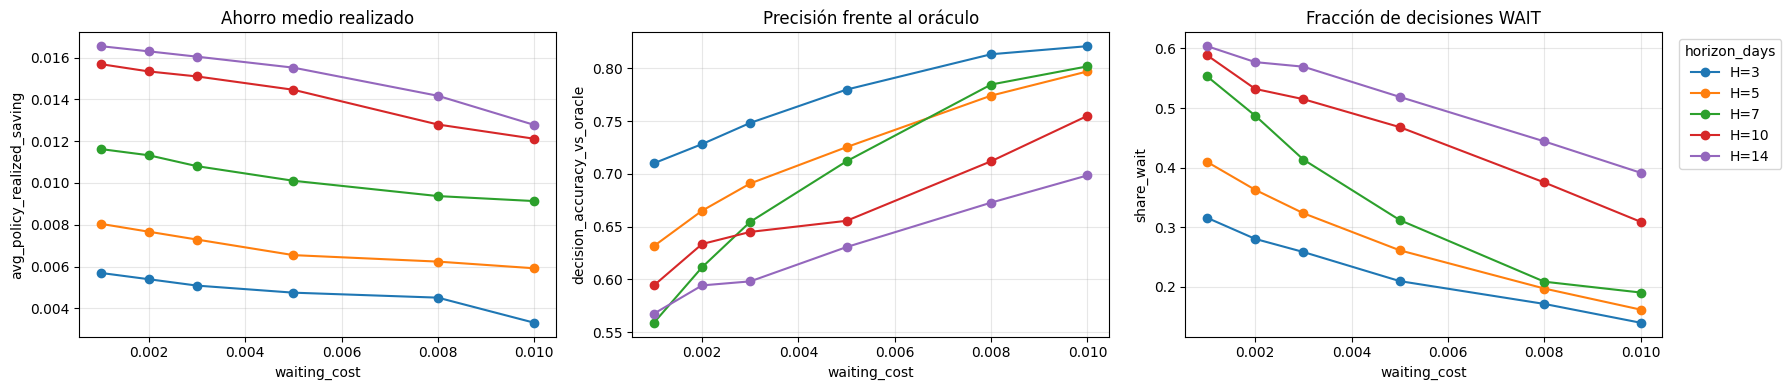

In [11]:
if not results.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for horizon_days in sorted(results["horizon_days"].unique()):
        sub = results[results["horizon_days"] == horizon_days].sort_values("waiting_cost")
        axes[0].plot(sub["waiting_cost"], sub["avg_policy_realized_saving"], marker="o", label=f"H={horizon_days}")
        axes[1].plot(sub["waiting_cost"], sub["decision_accuracy_vs_oracle"], marker="o", label=f"H={horizon_days}")
        axes[2].plot(sub["waiting_cost"], sub["share_wait"], marker="o", label=f"H={horizon_days}")

    axes[0].set_title("Ahorro medio realizado")
    axes[1].set_title("Precisión frente al oráculo")
    axes[2].set_title("Fracción de decisiones WAIT")
    for ax in axes:
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("waiting_cost")
    axes[0].set_ylabel("avg_policy_realized_saving")
    axes[1].set_ylabel("decision_accuracy_vs_oracle")
    axes[2].set_ylabel("share_wait")
    axes[2].legend(title="horizon_days", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No hay resultados para graficar. Revisa la tabla failures.")


## 10. Selección de la mejor combinación


In [12]:
if ranked.empty:
    best = None
    print("No hay configuraciones válidas para seleccionar.")
else:
    best = ranked.iloc[0].to_dict()
    display(best)


{'horizon_days': 14,
 'waiting_cost': 0.001,
 'rows': 1045,
 'decision_accuracy_vs_oracle': 0.5674641148325359,
 'share_wait': 0.6038277511961723,
 'avg_realized_wait_gain': 0.013630622009569378,
 'avg_policy_realized_saving': 0.016548325358851677,
 'mae_q20': 0.03515043505209264,
 'pinball_q20': 0.009068592212267875,
 'mae_q50': 0.021410367416431254,
 'pinball_q50': 0.010705183708215627,
 'rmse_q50': 0.036358156746981465,
 'mae_q80': 0.022694326856590313,
 'pinball_q80': 0.00802797594688196,
 'rows_train': 45609,
 'rows_test': 1045,
 'train_end_date': '2025-12-31',
 'fit_elapsed_seconds': 216.13108400000056}

In [13]:
if best is not None:
    BEST_HORIZON = int(best["horizon_days"])
    BEST_WAITING_COST = float(best["waiting_cost"])
    print("BEST_HORIZON =", BEST_HORIZON)
    print("BEST_WAITING_COST =", BEST_WAITING_COST)


BEST_HORIZON = 14
BEST_WAITING_COST = 0.001


## 11. Recomendaciones más recientes


In [14]:
if best is not None:
    latest_best = artifacts[BEST_HORIZON]["latest_outputs"][BEST_WAITING_COST].copy()
    latest_best["expected_gain_q50"] = latest_best["price"] - latest_best["pred_q50"]
    latest_best["probable_gain_q80"] = latest_best["price"] - latest_best["pred_q80"]
    display(latest_best.head(20))
else:
    print("No hay recomendaciones porque no se pudo seleccionar un mejor modelo.")


,date,station_id,price,regime,pred_q20,pred_q50,pred_q80,target_min_14d,decision,realized_wait_gain,policy_realized_saving,oracle_best_action,expected_gain_q50,probable_gain_q80
0,2026-03-24,13562,1.639,shock_down,1.594793,1.615834,1.656485,NaN,buy_now,NaN,0.0,buy_now,0.023166,-0.017485
1,2026-03-24,15740,1.659,shock_down,1.641654,1.676085,1.682564,NaN,buy_now,NaN,0.0,buy_now,-0.017085,-0.023564
2,2026-03-24,16398,1.659,shock_down,1.641654,1.676085,1.684477,NaN,buy_now,NaN,0.0,buy_now,-0.017085,-0.025477
3,2026-03-24,15366,1.689,shock_down,1.679486,1.693529,1.703143,NaN,buy_now,NaN,0.0,buy_now,-0.004529,-0.014143
4,2026-03-24,14084,1.699,shock_down,1.706887,1.712720,1.733500,NaN,buy_now,NaN,0.0,buy_now,-0.013720,-0.034500
5,2026-03-24,15390,1.700,shock_down,1.702643,1.710874,1.727172,NaN,buy_now,NaN,0.0,buy_now,-0.010874,-0.027172
6,2026-03-24,13973,1.709,shock_down,1.710827,1.714571,1.737361,NaN,buy_now,NaN,0.0,buy_now,-0.005571,-0.028361
7,2026-03-24,14016,1.759,shock_down,1.733878,1.751994,1.758363,NaN,buy_now,NaN,0.0,buy_now,0.007006,0.000637
8,2026-03-24,10945,1.808,shock_down,1.760114,1.785603,1.794326,NaN,wait,NaN,NaN,buy_now,0.022397,0.013674
9,2026-03-24,4157,1.809,shock_down,1.754632,1.789867,1.790951,NaN,wait,NaN,NaN,buy_now,0.019133,0.018049


## 12. Backtest rolling


In [22]:
RUN_ROLLING_BACKTEST = True

ROLLING_MIN_TRAIN_DAYS = 365 * 2
ROLLING_TEST_WINDOW_DAYS = 30
ROLLING_STEP_DAYS = 30
ROLLING_MAX_FOLDS = 12

Esta sección repite entrenamiento y evaluación en varios cortes temporales.

Ventajas:

- reduce dependencia de un único split temporal
- permite estimar mejor la estabilidad de `horizon_days` y `waiting_cost`
- muestra progreso por horizonte y por fold


In [23]:
def _prepare_horizon_frame(panel_df: pd.DataFrame, fuel_col: str, horizon_days: int) -> dict[str, Any]:
    model = FuelDecisionModelA(
        fuel_col=fuel_col,
        horizon_days=horizon_days,
        train_end_date=None,
        waiting_cost=0.003,
    )

    frame = model.build_training_frame(panel_df)
    if frame.empty:
        raise ValueError("build_training_frame devolvió un DataFrame vacío.")

    required_cols = {"is_observed_price", "target_available", "price", "date", "station_id", "regime"}
    missing = sorted(required_cols - set(frame.columns))
    if missing:
        raise ValueError(f"El frame rolling no contiene columnas requeridas: {missing}")

    target_col = f"target_min_{horizon_days}d"
    if target_col not in frame.columns:
        raise ValueError(f"No existe la columna target esperada: {target_col}")

    eligible = frame[(frame["is_observed_price"] == 1) & (frame["target_available"] == 1)].copy()
    eligible = eligible.dropna(subset=["price", target_col]).copy()
    eligible["date"] = pd.to_datetime(eligible["date"])

    if eligible.empty:
        raise ValueError("No hay filas elegibles para el backtest rolling.")

    return {"model": model, "frame": frame, "eligible": eligible, "target_col": target_col}


def _rolling_cutoffs(
    eligible: pd.DataFrame,
    min_train_days: int,
    test_window_days: int,
    step_days: int,
    max_folds: int | None = None,
) -> list[pd.Timestamp]:
    min_date = pd.to_datetime(eligible["date"]).min()
    max_date = pd.to_datetime(eligible["date"]).max()

    first_cutoff = min_date + pd.Timedelta(days=min_train_days)
    last_cutoff = max_date - pd.Timedelta(days=test_window_days)

    if first_cutoff > last_cutoff:
        return []

    cutoffs = []
    current = first_cutoff
    while current <= last_cutoff:
        cutoffs.append(pd.Timestamp(current))
        current = current + pd.Timedelta(days=step_days)

    if max_folds is not None and len(cutoffs) > max_folds:
        cutoffs = cutoffs[-max_folds:]

    return cutoffs


def run_rolling_backtest_for_horizon(
    panel_df: pd.DataFrame,
    fuel_col: str,
    horizon_days: int,
    waiting_cost_candidates: list[float],
    min_train_days: int,
    test_window_days: int,
    step_days: int,
    max_folds: int | None = None,
    show_progress: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    prep = _prepare_horizon_frame(panel_df, fuel_col, horizon_days)
    model = prep["model"]
    eligible = prep["eligible"]
    target_col = prep["target_col"]

    cutoffs = _rolling_cutoffs(
        eligible=eligible,
        min_train_days=min_train_days,
        test_window_days=test_window_days,
        step_days=step_days,
        max_folds=max_folds,
    )

    if not cutoffs:
        raise ValueError("No se pudieron generar folds rolling. Reduce min_train_days o test_window_days.")

    fold_rows = []
    policy_rows = []

    fold_iter = cutoffs
    if show_progress:
        fold_iter = tqdm(cutoffs, desc=f"Rolling folds (H={horizon_days})", unit="fold", leave=False)

    for fold_id, cutoff in enumerate(fold_iter, start=1):
        train_df = eligible[eligible["date"] <= cutoff].copy()
        test_end = cutoff + pd.Timedelta(days=test_window_days)
        test_df = eligible[(eligible["date"] > cutoff) & (eligible["date"] <= test_end)].copy()

        if train_df.empty or test_df.empty:
            continue

        t0 = time.perf_counter()
        model.forecaster.fit(
            train_df,
            feature_columns=model.feature_columns_,
            target_column=target_col,
        )
        pred_test = model.forecaster.predict(test_df.copy())
        forecast_metrics = evaluate_predictions_local(pred_test, target_col)

        fold_rows.append(
            {
                "horizon_days": horizon_days,
                "fold_id": fold_id,
                "cutoff_date": str(pd.Timestamp(cutoff).date()),
                "test_end_date": str(pd.Timestamp(test_end).date()),
                "rows_train": len(train_df),
                "rows_test": len(test_df),
                "fit_elapsed_seconds": time.perf_counter() - t0,
                **forecast_metrics,
            }
        )

        base_test_cols = ["date", "station_id", "price", "regime", "pred_q20", "pred_q50", "pred_q80", target_col]
        test_eval = pred_test[base_test_cols].copy()

        cost_iter = waiting_cost_candidates
        if show_progress:
            cost_iter = tqdm(waiting_cost_candidates, desc=f"waiting_cost (H={horizon_days}, fold={fold_id})", unit="cost", leave=False)

        for waiting_cost in cost_iter:
            policy = WaitBuyDecisionPolicy(waiting_cost=waiting_cost)
            summary = policy.summarize(test_eval.copy())
            policy_rows.append(
                {
                    "horizon_days": horizon_days,
                    "fold_id": fold_id,
                    "cutoff_date": str(pd.Timestamp(cutoff).date()),
                    "waiting_cost": waiting_cost,
                    **summary,
                }
            )

    return pd.DataFrame(fold_rows), pd.DataFrame(policy_rows)


def calibrate_model_a_rolling(
    panel_df: pd.DataFrame,
    fuel_col: str,
    horizon_candidates: list[int],
    waiting_cost_candidates: list[float],
    min_train_days: int,
    test_window_days: int,
    step_days: int,
    max_folds: int | None = None,
    show_progress: bool = True,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    fold_frames = []
    policy_frames = []
    failures = []

    iterator = horizon_candidates
    if show_progress:
        iterator = tqdm(horizon_candidates, desc="Rolling por horizon_days", unit="horizon")

    for horizon_days in iterator:
        try:
            fold_df, policy_df = run_rolling_backtest_for_horizon(
                panel_df=panel_df,
                fuel_col=fuel_col,
                horizon_days=horizon_days,
                waiting_cost_candidates=waiting_cost_candidates,
                min_train_days=min_train_days,
                test_window_days=test_window_days,
                step_days=step_days,
                max_folds=max_folds,
                show_progress=show_progress,
            )
            if not fold_df.empty:
                fold_frames.append(fold_df)
            if not policy_df.empty:
                policy_frames.append(policy_df)
        except Exception as e:
            failures.append(
                {
                    "horizon_days": horizon_days,
                    "error": repr(e),
                    "traceback": traceback.format_exc(),
                }
            )

    fold_results = pd.concat(fold_frames, ignore_index=True) if fold_frames else pd.DataFrame()
    policy_results = pd.concat(policy_frames, ignore_index=True) if policy_frames else pd.DataFrame()
    failure_df = pd.DataFrame(failures)
    return fold_results, policy_results, failure_df


def summarize_rolling_results(
    fold_results: pd.DataFrame,
    policy_results: pd.DataFrame,
) -> pd.DataFrame:
    if policy_results.empty:
        return pd.DataFrame()

    policy_summary = (
        policy_results
        .groupby(["horizon_days", "waiting_cost"], as_index=False)
        .agg(
            folds=("fold_id", "nunique"),
            avg_policy_realized_saving=("avg_policy_realized_saving", "mean"),
            median_policy_realized_saving=("avg_policy_realized_saving", "median"),
            decision_accuracy_vs_oracle=("decision_accuracy_vs_oracle", "mean"),
            share_wait=("share_wait", "mean"),
            avg_realized_wait_gain=("avg_realized_wait_gain", "mean"),
        )
    )

    if fold_results.empty:
        return policy_summary

    forecast_summary = (
        fold_results
        .groupby("horizon_days", as_index=False)
        .agg(
            mae_q20=("mae_q20", "mean"),
            mae_q50=("mae_q50", "mean"),
            mae_q80=("mae_q80", "mean"),
            rmse_q50=("rmse_q50", "mean"),
            rows_train_mean=("rows_train", "mean"),
            rows_test_mean=("rows_test", "mean"),
            fit_elapsed_seconds_mean=("fit_elapsed_seconds", "mean"),
        )
    )

    return policy_summary.merge(forecast_summary, on="horizon_days", how="left")


def rank_rolling_results(
    rolling_summary: pd.DataFrame,
    primary_sort_metric: str = "avg_policy_realized_saving",
    min_share_wait: float | None = None,
    max_share_wait: float | None = None,
) -> pd.DataFrame:
    if rolling_summary.empty:
        return rolling_summary.copy()

    work = rolling_summary.copy()
    if min_share_wait is not None:
        work = work[work["share_wait"] >= min_share_wait]
    if max_share_wait is not None:
        work = work[work["share_wait"] <= max_share_wait]

    if work.empty:
        return work

    return work.sort_values(
        by=[primary_sort_metric, "decision_accuracy_vs_oracle", "mae_q50"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

In [24]:
if RUN_ROLLING_BACKTEST:
    t0 = time.perf_counter()
    rolling_fold_results, rolling_policy_results, rolling_failures = calibrate_model_a_rolling(
        panel_df=panel,
        fuel_col=FUEL_COL,
        horizon_candidates=HORIZON_CANDIDATES,
        waiting_cost_candidates=WAITING_COST_CANDIDATES,
        min_train_days=ROLLING_MIN_TRAIN_DAYS,
        test_window_days=ROLLING_TEST_WINDOW_DAYS,
        step_days=ROLLING_STEP_DAYS,
        max_folds=ROLLING_MAX_FOLDS,
        show_progress=True,
    )
    rolling_summary = summarize_rolling_results(rolling_fold_results, rolling_policy_results)
    elapsed = time.perf_counter() - t0
    print(f"Backtest rolling completado en {elapsed:.1f}s")
    display(rolling_summary.head())
    if not rolling_failures.empty:
        print("Horizontes con error en rolling:")
        display(rolling_failures[["horizon_days", "error"]])
        print("Primer traceback rolling:")
        print(rolling_failures.iloc[0]["traceback"])
else:
    print("Pon RUN_ROLLING_BACKTEST = True para ejecutar esta sección.")
    rolling_fold_results = pd.DataFrame()
    rolling_policy_results = pd.DataFrame()
    rolling_summary = pd.DataFrame()
    rolling_failures = pd.DataFrame()

Rolling por horizon_days:   0%|          | 0/5 [00:00<?, ?horizon/s]























Rolling por horizon_days:  20%|██        | 1/5 [42:06<2:48:26, 2526.62s/horizon]























Rolling por horizon_days:  40%|████      | 2/5 [1:25:03<2:07:48, 2556.24s/horizon]























Rolling por horizon_days:  60%|██████    | 3/5 [2:08:19<1:25:48, 2574.33s/horizon]























Rolling por horizon_days:  80%|████████  | 4/5 [2:51:04<42:50, 2570.69s/horizon]  























Rolling por horizon_days: 100%|██████████| 5/5 [4:03:07<00:00, 2917.58s/horizon]

Backtest rolling completado en 14587.9s


,horizon_days,waiting_cost,folds,avg_policy_realized_saving,median_policy_realized_saving,decision_accuracy_vs_oracle,share_wait,avg_realized_wait_gain,mae_q20,mae_q50,mae_q80,rmse_q50,rows_train_mean,rows_test_mean,fit_elapsed_seconds_mean
0,3,0.001,12,0.001731,0.001408,0.639709,0.324104,0.001706,0.014031,0.009261,0.011883,0.015304,44192.833333,362.0,210.464662
1,3,0.002,12,0.001358,0.001209,0.681569,0.250571,0.001706,0.014031,0.009261,0.011883,0.015304,44192.833333,362.0,210.464662
2,3,0.003,12,0.001109,0.000923,0.705265,0.199486,0.001706,0.014031,0.009261,0.011883,0.015304,44192.833333,362.0,210.464662
3,3,0.005,12,0.000753,0.000620,0.725650,0.146866,0.001706,0.014031,0.009261,0.011883,0.015304,44192.833333,362.0,210.464662
4,3,0.008,12,0.000346,0.000301,0.751090,0.083365,0.001706,0.014031,0.009261,0.011883,0.015304,44192.833333,362.0,210.464662


In [25]:
if not rolling_summary.empty:
    rolling_ranked = rank_rolling_results(
        rolling_summary,
        primary_sort_metric=PRIMARY_SORT_METRIC,
        min_share_wait=MIN_SHARE_WAIT,
        max_share_wait=MAX_SHARE_WAIT,
    )
    if rolling_ranked.empty and not rolling_summary.empty:
        print("El ranking rolling filtrado quedó vacío. Mostrando ranking rolling sin filtros de share_wait.")
        rolling_ranked = rank_rolling_results(
            rolling_summary,
            primary_sort_metric=PRIMARY_SORT_METRIC,
        )
    display(rolling_ranked)
else:
    rolling_ranked = pd.DataFrame()
    print("rolling_summary está vacío.")

,horizon_days,waiting_cost,folds,avg_policy_realized_saving,median_policy_realized_saving,decision_accuracy_vs_oracle,share_wait,avg_realized_wait_gain,mae_q20,mae_q50,mae_q80,rmse_q50,rows_train_mean,rows_test_mean,fit_elapsed_seconds_mean
0,14,0.001,12,0.010811,0.007226,0.607162,0.578878,0.014592,0.023686,0.017797,0.020669,0.024376,44203.250000,362.083333,360.175981
1,14,0.002,12,0.009735,0.006177,0.593286,0.534182,0.014592,0.023686,0.017797,0.020669,0.024376,44203.250000,362.083333,360.175981
2,14,0.003,12,0.008924,0.005730,0.587520,0.504625,0.014592,0.023686,0.017797,0.020669,0.024376,44203.250000,362.083333,360.175981
3,10,0.001,12,0.007938,0.005453,0.573434,0.543682,0.010702,0.022831,0.015839,0.017801,0.022274,44200.250000,362.083333,213.671029
4,14,0.005,12,0.007199,0.004485,0.566269,0.420044,0.014592,0.023686,0.017797,0.020669,0.024376,44203.250000,362.083333,360.175981
5,10,0.002,12,0.006930,0.004612,0.577898,0.486427,0.010702,0.022831,0.015839,0.017801,0.022274,44200.250000,362.083333,213.671029
6,10,0.003,12,0.006162,0.003809,0.584386,0.432086,0.010702,0.022831,0.015839,0.017801,0.022274,44200.250000,362.083333,213.671029
7,7,0.001,12,0.005336,0.003973,0.555146,0.507381,0.007250,0.020179,0.013613,0.015192,0.020076,44197.833333,362.000000,216.238010
8,14,0.008,12,0.005325,0.003125,0.556879,0.307938,0.014592,0.023686,0.017797,0.020669,0.024376,44203.250000,362.083333,360.175981
9,10,0.005,12,0.004826,0.002715,0.563296,0.342720,0.010702,0.022831,0.015839,0.017801,0.022274,44200.250000,362.083333,213.671029


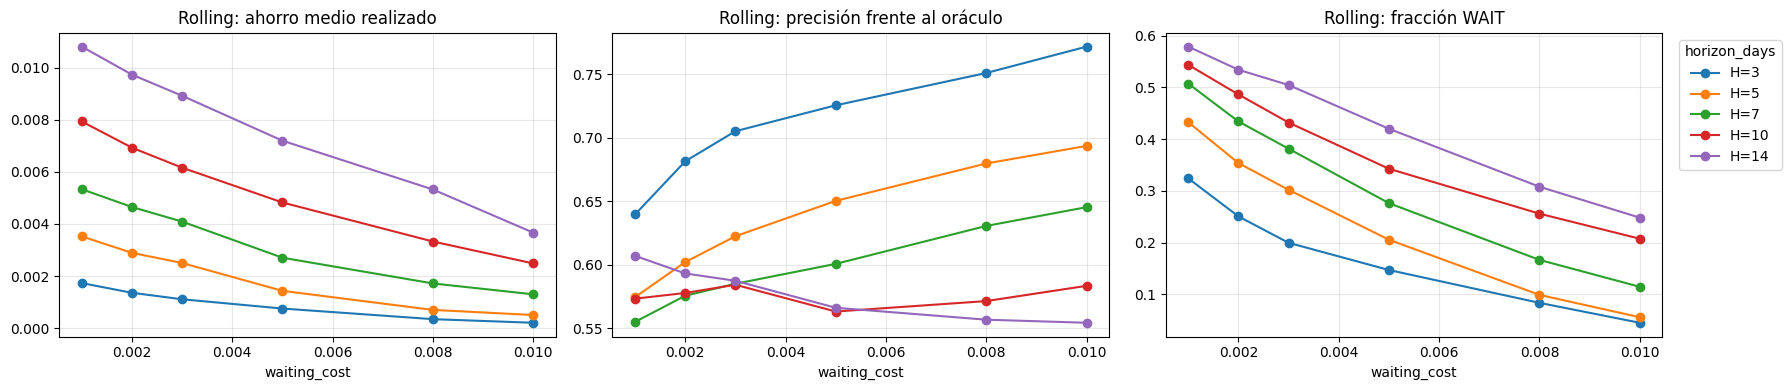

In [26]:
if not rolling_summary.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for horizon_days in sorted(rolling_summary["horizon_days"].unique()):
        sub = rolling_summary[rolling_summary["horizon_days"] == horizon_days].sort_values("waiting_cost")
        axes[0].plot(sub["waiting_cost"], sub["avg_policy_realized_saving"], marker="o", label=f"H={horizon_days}")
        axes[1].plot(sub["waiting_cost"], sub["decision_accuracy_vs_oracle"], marker="o", label=f"H={horizon_days}")
        axes[2].plot(sub["waiting_cost"], sub["share_wait"], marker="o", label=f"H={horizon_days}")

    axes[0].set_title("Rolling: ahorro medio realizado")
    axes[1].set_title("Rolling: precisión frente al oráculo")
    axes[2].set_title("Rolling: fracción WAIT")

    for ax in axes:
        ax.set_xlabel("waiting_cost")
        ax.grid(True, alpha=0.3)

    axes[2].legend(title="horizon_days", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

In [27]:
OUTPUT_DIR = REPO_ROOT / "data" / "experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not rolling_fold_results.empty:
    rolling_fold_results.to_csv(OUTPUT_DIR / f"model_a_rolling_folds_{FUEL_COL}.csv", index=False)
if not rolling_policy_results.empty:
    rolling_policy_results.to_csv(OUTPUT_DIR / f"model_a_rolling_policy_{FUEL_COL}.csv", index=False)
if not rolling_summary.empty:
    rolling_summary.to_csv(OUTPUT_DIR / f"model_a_rolling_summary_{FUEL_COL}.csv", index=False)

print("Resultados rolling guardados en:", OUTPUT_DIR)

Resultados rolling guardados en: /Users/juanlu/Repositorios/FuelPrice-Predictor/data/experiments


## 12. Guardar resultados


In [28]:
OUTPUT_DIR = REPO_ROOT / "data" / "experiments"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if not ranked.empty:
    ranked_path = OUTPUT_DIR / f"model_a_calibration_{FUEL_COL}.csv"
    ranked.to_csv(ranked_path, index=False)
    print("Guardado ranking en:", ranked_path)

if best is not None:
    latest_path = OUTPUT_DIR / f"model_a_latest_best_{FUEL_COL}.csv"
    latest_best.to_csv(latest_path, index=False)
    print("Guardadas recomendaciones en:", latest_path)

if not failures.empty:
    failures_path = OUTPUT_DIR / f"model_a_failures_{FUEL_COL}.csv"
    failures.to_csv(failures_path, index=False)
    print("Guardados fallos en:", failures_path)


Guardado ranking en: /Users/juanlu/Repositorios/FuelPrice-Predictor/data/experiments/model_a_calibration_precio_gasoleo_a.csv
Guardadas recomendaciones en: /Users/juanlu/Repositorios/FuelPrice-Predictor/data/experiments/model_a_latest_best_precio_gasoleo_a.csv
